# AI Plastic Waste Classification System
## Comprehensive Analysis and Classification

**Dataset**: wastesegregation.v1i.multiclass

**Objectives**:
1. Analyze CSV structure and label mapping
2. Extract plastic types from image filenames
3. Create comprehensive label mapping
4. Display sample images from each category
5. Analyze class distribution and data quality

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
print('✅ Libraries imported')

✅ Libraries imported


## 1. Dataset Analysis

In [2]:
DATASET_PATH = r'c:\Users\vimal\OneDrive\Desktop\FINAL AIML\Waste segregation.v1i.multiclass'
TRAIN_DIR = os.path.join(DATASET_PATH, 'train')
TEST_DIR = os.path.join(DATASET_PATH, 'test')
VALID_DIR = os.path.join(DATASET_PATH, 'valid')

train_csv = pd.read_csv(os.path.join(TRAIN_DIR, '_classes.csv'))
test_csv = pd.read_csv(os.path.join(TEST_DIR, '_classes.csv'))
valid_csv = pd.read_csv(os.path.join(VALID_DIR, '_classes.csv'))

print('Dataset splits:')
print(f'  Train: {len(train_csv)} images')
print(f'  Test: {len(test_csv)} images')
print(f'  Valid: {len(valid_csv)} images')
print(f'\nCSV structure:\n{train_csv.head()}')

Dataset splits:
  Train: 6084 images
  Test: 1033 images
  Valid: 1731 images

CSV structure:
                                            filename  Plastic
0  OTHERS-499_jpg.rf.e1b170ac9cf6723a978b4acfa45e...        1
1  OTHERS-497_jpg.rf.54694e4df6af34e7ecb8b286d613...        1
2  OTHERS-498_jpg.rf.d5231c0dd06c6234cd725ad35b1c...        1
3  OTHERS-1255_jpg.rf.50dc38ba5c1c3783324edbee8ff...        1
4  OTHERS-712_jpg.rf.66d23b613305fbc92f363e1c4527...        1


## 2. Extract Plastic Types

In [3]:
def extract_plastic_type(filename):
    match = re.match(r'^([A-Z]+)', filename)
    if match:
        plastic_type = match.group(1)
        if plastic_type in ['HDPE', 'LDPE', 'PET', 'PP', 'PS', 'PVC', 'OTHERS']:
            return plastic_type
    return 'UNKNOWN'

train_csv['plastic_type'] = train_csv['filename'].apply(extract_plastic_type)
test_csv['plastic_type'] = test_csv['filename'].apply(extract_plastic_type)
valid_csv['plastic_type'] = valid_csv['filename'].apply(extract_plastic_type)

train_csv = train_csv[train_csv['plastic_type'] != 'UNKNOWN']
test_csv = test_csv[test_csv['plastic_type'] != 'UNKNOWN']
valid_csv = valid_csv[valid_csv['plastic_type'] != 'UNKNOWN']

print(f'Plastic types: {sorted(train_csv["plastic_type"].unique())}')

Plastic types: ['HDPE', 'LDPE', 'OTHERS', 'PET', 'PP', 'PS']


## 3. Plastic Type Mapping

In [4]:
PLASTIC_INFO = {
    'PET': {'code': 1, 'name': 'Polyethylene Terephthalate', 'uses': 'Water bottles, food containers', 'symbol': '♳ #1'},
    'HDPE': {'code': 2, 'name': 'High-Density Polyethylene', 'uses': 'Milk jugs, detergent bottles', 'symbol': '♴ #2'},
    'PVC': {'code': 3, 'name': 'Polyvinyl Chloride', 'uses': 'Pipes, credit cards', 'symbol': '♵ #3'},
    'LDPE': {'code': 4, 'name': 'Low-Density Polyethylene', 'uses': 'Plastic bags, squeeze bottles', 'symbol': '♶ #4'},
    'PP': {'code': 5, 'name': 'Polypropylene', 'uses': 'Yogurt containers, bottle caps', 'symbol': '♷ #5'},
    'PS': {'code': 6, 'name': 'Polystyrene', 'uses': 'Foam cups, takeout containers', 'symbol': '♸ #6'},
    'OTHERS': {'code': 7, 'name': 'Other Plastics', 'uses': 'Multi-layer plastics', 'symbol': '♹ #7'}
}

plastic_types = sorted([k for k in PLASTIC_INFO.keys() if k in train_csv['plastic_type'].unique()])
class_to_idx = {cls: idx for idx, cls in enumerate(plastic_types)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}

train_csv['label'] = train_csv['plastic_type'].map(class_to_idx)
test_csv['label'] = test_csv['plastic_type'].map(class_to_idx)
valid_csv['label'] = valid_csv['plastic_type'].map(class_to_idx)

for pt in plastic_types:
    info = PLASTIC_INFO[pt]
    print(f"{info['symbol']} {pt} (Label {class_to_idx[pt]}): {info['name']}\n  Uses: {info['uses']}")

♴ #2 HDPE (Label 0): High-Density Polyethylene
  Uses: Milk jugs, detergent bottles
♶ #4 LDPE (Label 1): Low-Density Polyethylene
  Uses: Plastic bags, squeeze bottles
♹ #7 OTHERS (Label 2): Other Plastics
  Uses: Multi-layer plastics
♳ #1 PET (Label 3): Polyethylene Terephthalate
  Uses: Water bottles, food containers
♷ #5 PP (Label 4): Polypropylene
  Uses: Yogurt containers, bottle caps
♸ #6 PS (Label 5): Polystyrene
  Uses: Foam cups, takeout containers


## 4. Class Distribution

              Train  Test  Valid  Total  Percentage
plastic_type                                       
HDPE           1035   134    285   1454       17.90
LDPE            637    78    161    876       10.78
OTHERS         1779   228    382   2389       29.41
PET            1629   225    445   2299       28.30
PP              524    67    137    728        8.96
PS              264    34     80    378        4.65


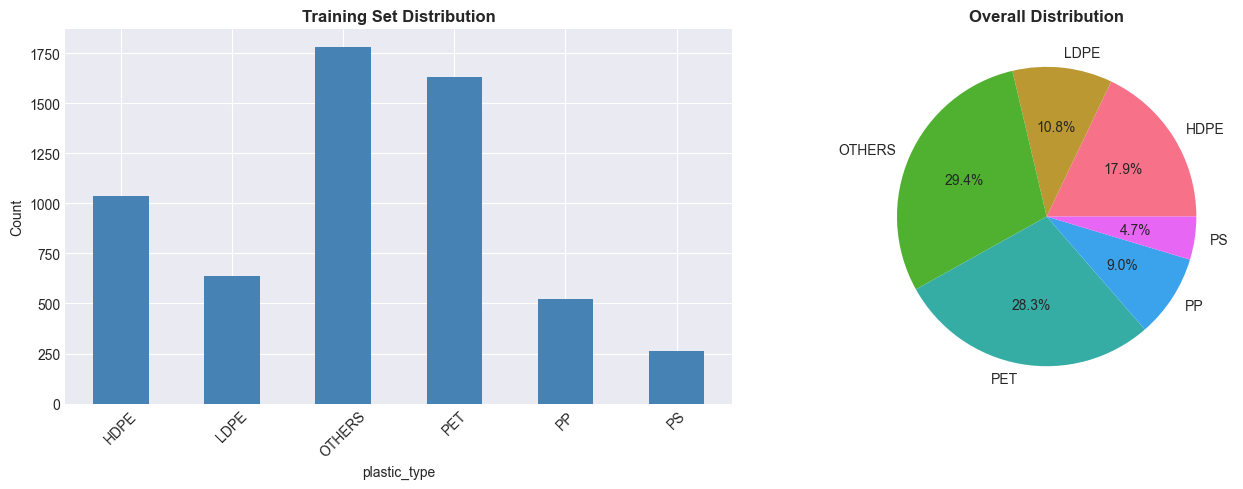

In [5]:
dist_df = pd.DataFrame({
    'Train': train_csv['plastic_type'].value_counts(),
    'Test': test_csv['plastic_type'].value_counts(),
    'Valid': valid_csv['plastic_type'].value_counts()
}).fillna(0).astype(int)

dist_df['Total'] = dist_df.sum(axis=1)
dist_df['Percentage'] = (dist_df['Total'] / dist_df['Total'].sum() * 100).round(2)
print(dist_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
dist_df['Train'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Training Set Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

dist_df['Percentage'].plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('Overall Distribution', fontweight='bold')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

## 5. Sample Images

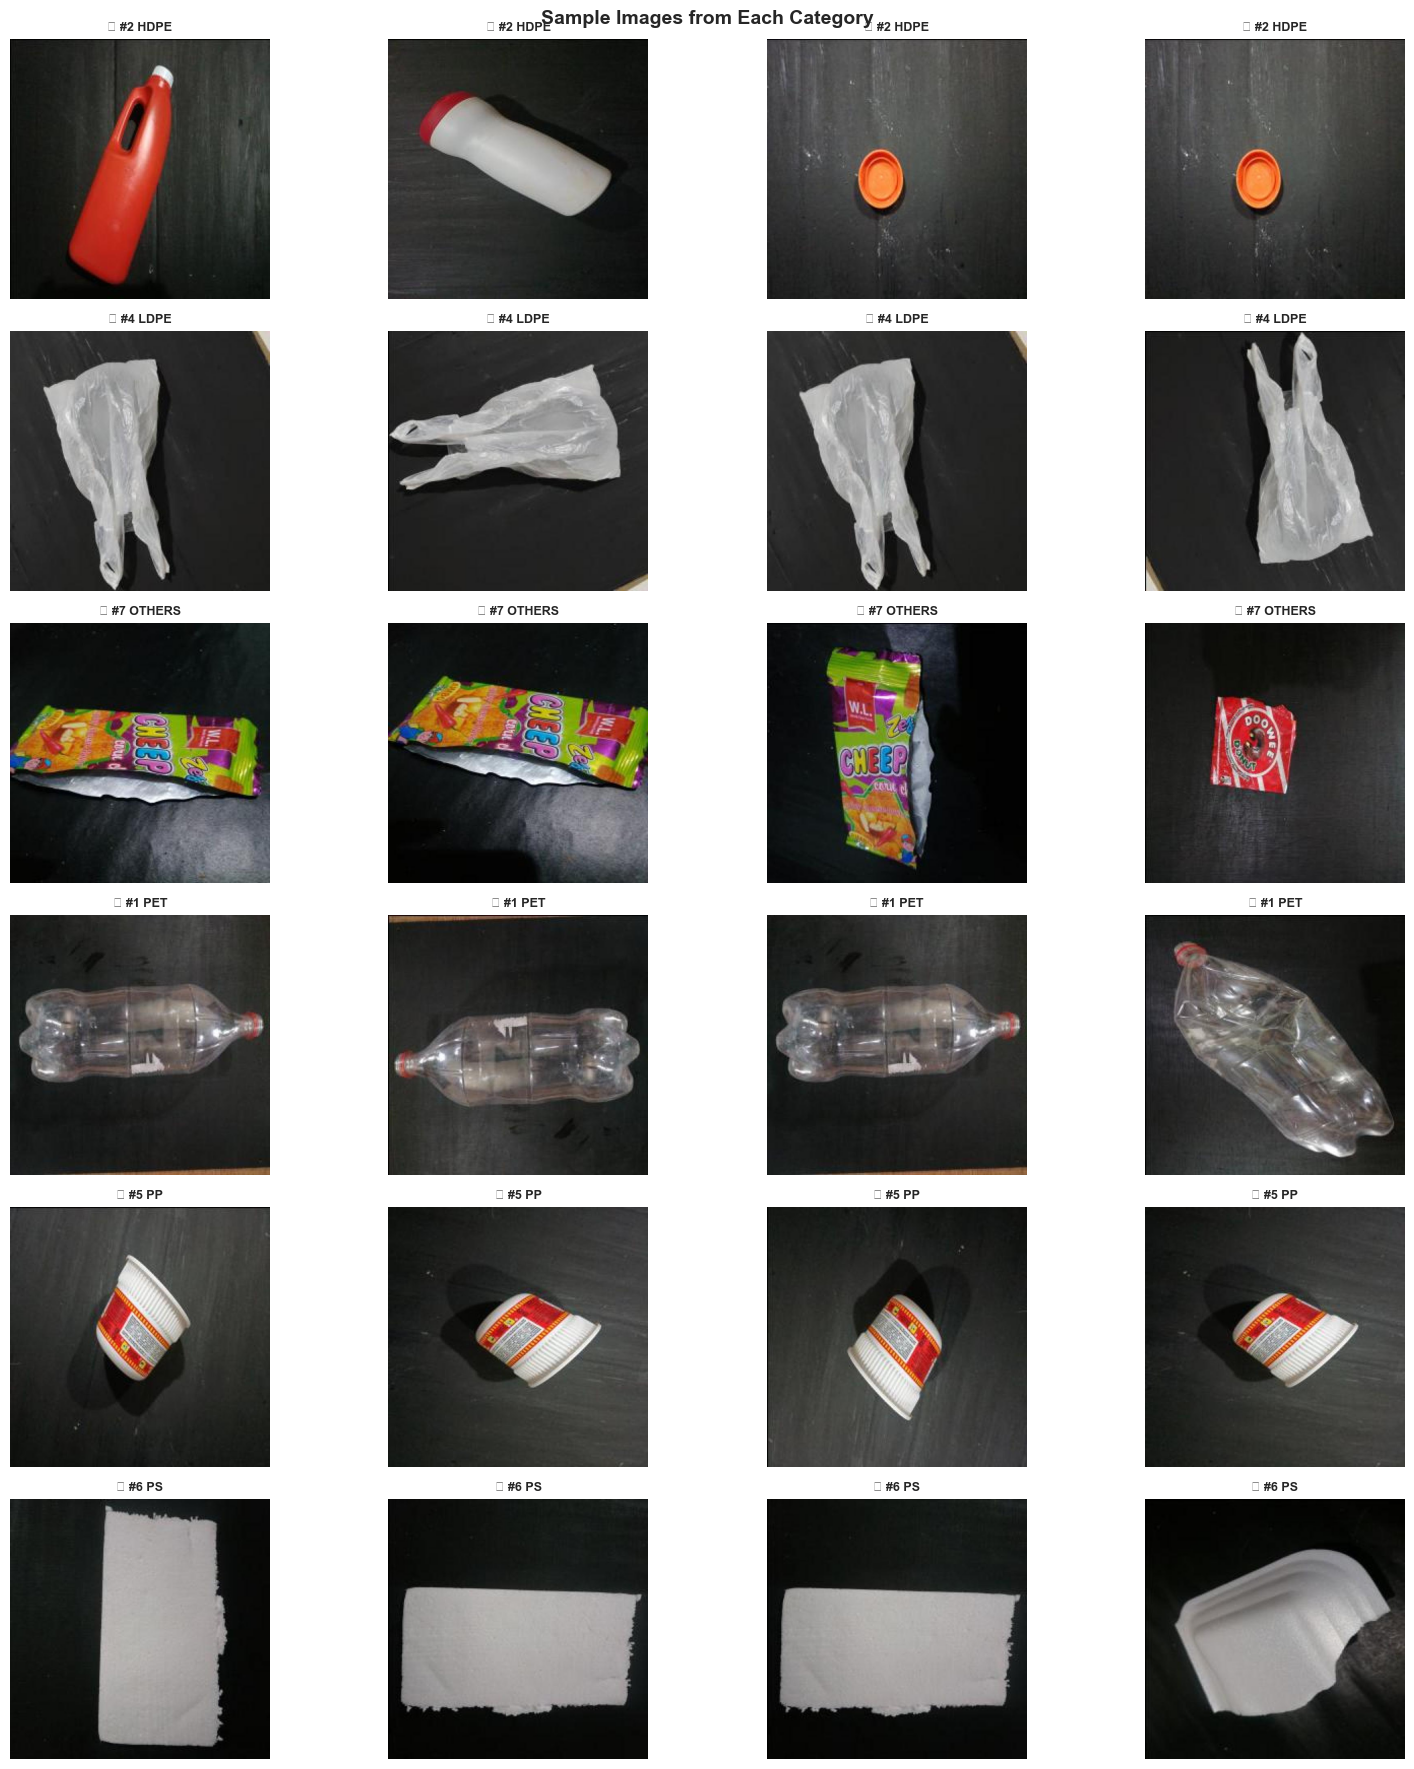

In [6]:
fig, axes = plt.subplots(len(plastic_types), 4, figsize=(16, len(plastic_types) * 3))
if len(plastic_types) == 1:
    axes = axes.reshape(1, -1)

for idx, plastic_type in enumerate(plastic_types):
    samples = train_csv[train_csv['plastic_type'] == plastic_type].head(4)
    for col, (_, row) in enumerate(samples.iterrows()):
        img_path = os.path.join(TRAIN_DIR, row['filename'])
        try:
            img = Image.open(img_path)
            axes[idx, col].imshow(img)
        except:
            axes[idx, col].text(0.5, 0.5, 'Not Found', ha='center', va='center')
        info = PLASTIC_INFO[plastic_type]
        axes[idx, col].set_title(f"{info['symbol']} {plastic_type}", fontsize=9, fontweight='bold')
        axes[idx, col].axis('off')

plt.suptitle('Sample Images from Each Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Image Quality Analysis

In [7]:
image_sizes = []
corrupted = 0
for _, row in train_csv.head(500).iterrows():
    try:
        with Image.open(os.path.join(TRAIN_DIR, row['filename'])) as img:
            image_sizes.append(img.size)
    except:
        corrupted += 1

if image_sizes:
    widths = [s[0] for s in image_sizes]
    heights = [s[1] for s in image_sizes]
    print(f'Width: Min={min(widths)}, Max={max(widths)}, Avg={np.mean(widths):.1f}')
    print(f'Height: Min={min(heights)}, Max={max(heights)}, Avg={np.mean(heights):.1f}')
    print(f'Corrupted: {corrupted}/500')

Width: Min=640, Max=640, Avg=640.0
Height: Min=640, Max=640, Avg=640.0
Corrupted: 0/500


## 7. Save Processed Data

In [8]:
import pickle
output_dir = os.path.join(DATASET_PATH, 'processed')
os.makedirs(output_dir, exist_ok=True)

train_csv.to_csv(os.path.join(output_dir, 'train_labeled.csv'), index=False)
test_csv.to_csv(os.path.join(output_dir, 'test_labeled.csv'), index=False)
valid_csv.to_csv(os.path.join(output_dir, 'valid_labeled.csv'), index=False)

mappings = {'class_to_idx': class_to_idx, 'idx_to_class': idx_to_class, 'plastic_info': PLASTIC_INFO}
with open(os.path.join(output_dir, 'label_mappings.pkl'), 'wb') as f:
    pickle.dump(mappings, f)

print('✅ Saved to processed/ folder')

✅ Saved to processed/ folder


## 8. Summary

In [ ]:
print('='*70)
print('CLASSIFICATION SYSTEM READY')
print('='*70)
print(f'Total images: {len(train_csv) + len(test_csv) + len(valid_csv)}')
print(f'Classes: {len(plastic_types)}')
print(f'Plastic types: {", ".join(plastic_types)}')
print('\nLabel mapping:')
for pt in plastic_types:
    print(f'  {pt} → {class_to_idx[pt]}')
print('\n✅ Ready for model training!')

CLASSIFICATION SYSTEM READY
Total images: 8124
Classes: 6
Plastic types: HDPE, LDPE, OTHERS, PET, PP, PS

Label mapping:
  HDPE → 0
  LDPE → 1
  OTHERS → 2
  PET → 3
  PP → 4
  PS → 5

✅ Ready for model training!


: 